In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

# Positive Definite Matrices (Bowl shape (convex upward))
convex optimization


In [3]:
# f(x,y) = 9x^2 + 12xy + 5y^2
# Symmeritic matrix 
A = np.asarray([[9,6],
                [6,5]])

K, x = np.linalg.eig(A) # K -> eigenvalue, x -> eigenvector

# cofficient ac > b^2
a = A[0, 0]
b = A[0, 1]
c = A[1, 1]

# diagonal elements are positive because x^T Ax > 0 (eig_val > 0)
d = x.T @ A @ x

# vectors
v1 = x[:, 0]
v2 = x[:, 1]
# matrix multiplication with vector v1 and v2 (matrix transformation)
Av1 = A @ v1
Av2 = A @ v2

# for simplicity
Ax = A @ x

# output
print(f"Tranformation of matrix A =\n {Ax}")
print(f'\nEigenvectors x =\n {x}')
print(f"\nEigenvalue K =\n {K}")
print(f"\nCheck Postive Definiteness:")
print(f"\nCofficient of quadratic ac > b^2 = {a*c > b**2}")
print(f"Is eigenvalue strictly positive = {np.all(K > 0)}")
print(f"\nDiagonal matrix=\n {np.round(d)}")


Tranformation of matrix A =
 [[10.80944137 -0.39493945]
 [ 7.79100453  0.54794922]]

Eigenvectors x =
 [[ 0.81124219 -0.58471028]
 [ 0.58471028  0.81124219]]

Eigenvalue K =
 [13.32455532  0.67544468]

Check Postive Definiteness:

Cofficient of quadratic ac > b^2 = True
Is eigenvalue strictly positive = True

Diagonal matrix=
 [[13.  0.]
 [-0.  1.]]


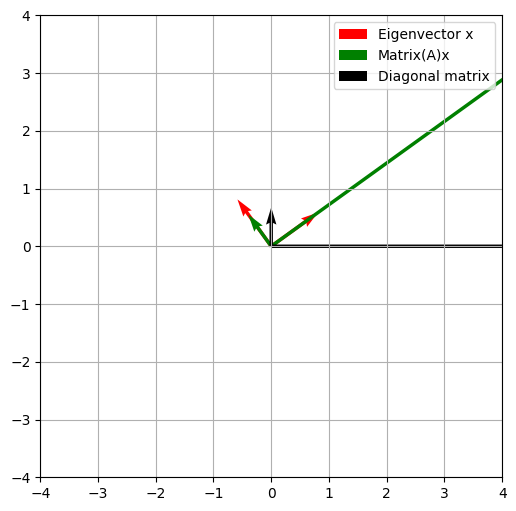

In [4]:
origin = np.zeros(x.shape)

fig, ax = plt.subplots(figsize=(8,6))

ax.quiver(*origin, *x, angles='xy', scale_units='xy', scale=1, color='r', label='Eigenvector x')
ax.quiver(*origin, *(A@x), angles='xy', scale_units='xy', scale=1, color='g', label='Matrix(A)x')
ax.quiver(*origin, *d, angles='xy', scale_units='xy', scale=1, color='k', label='Diagonal matrix')


# eigenvectors
# ax.quiver(*[0,0], *v1, angles='xy', scale_units='xy', scale=1, color='r', label='vector v1')
# ax.quiver(*[0,0], *v2, angles='xy', scale_units='xy', scale=1, color='r', label='vector v2')

# # matrix transformed
# ax.quiver(*[0,0], *Av1, angles='xy', scale_units='xy', scale=1, color='k', label='Matrix(A)v1')
# ax.quiver(*[0,0], *Av2, angles='xy', scale_units='xy', scale=1, color='r', label='Matrix(A)v2')


ax.grid()
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
ax.set_aspect('equal')
ax.legend()

plt.show()

In [5]:
A = np.array([[3,1,4],
              [1,5,6],
              [4,6,8]])

val,x = np.linalg.eig(A)
origin = np.eye(A.shape[0])

xT = x.T
Ax = A @ x
res = xT @ Ax
# res = x.T @ A @ x

print(x)
print(Ax)
print(np.round(res))

[[-0.32929278 -0.78498777 -0.524748  ]
 [-0.5488213   0.6113458  -0.57013287]
 [-0.76834982 -0.10025224  0.63212977]]
[[ -4.61009892  -2.14462648   0.3841422 ]
 [ -7.6834982    1.67022778   0.41736623]
 [-10.75689748  -0.27389421  -0.46275111]]
[[14. -0.  0.]
 [-0.  3.  0.]
 [ 0.  0. -1.]]


# 3D view

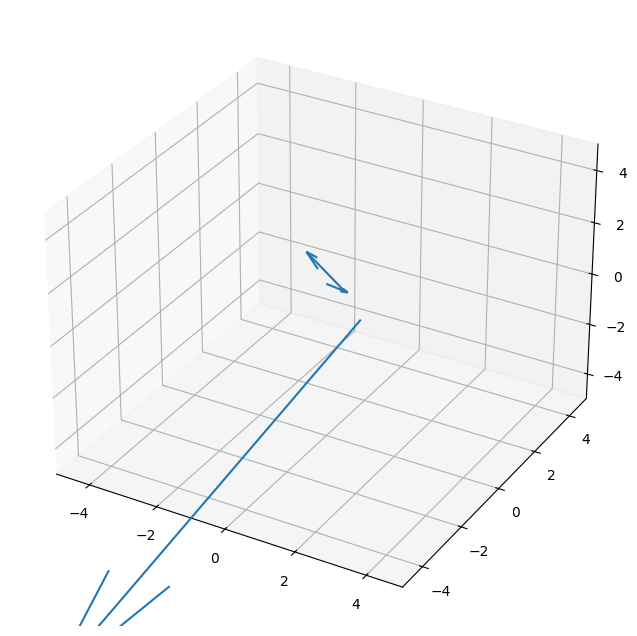

In [6]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(projection='3d')
# ax.quiver(*origin, *x )
ax.quiver(*origin, *Ax)


ax.grid()
ax.set_xlim3d(-5,5)
ax.set_ylim3d(-5,5)
ax.set_zlim3d(-5,5)


plt.show()

# Cholesky Decomposition
A positive matrices can be factorized into product A = LL^T. Where L is lower triangular matrix, Cholesky of A and also L is unique.


first we take a random matrix -> constructed SPD matrix A -> factorized into product  A = LL^T



Cholesky decomposition is independent of how matrix A was created.

In [7]:
# Arbitrary matrix 
matrix = np.array([[2,5,4],
                   [1,5,6],
                   [4,6,3]])

# construct SPD matrix
cov = matrix @ matrix.T 

# Eigenvalue and Eigenvector
eig_val, eig_vec = np.linalg.eigh(cov)
# eig_val = np.diag(eig_val)

rk = np.linalg.matrix_rank(matrix)

# Factorization into product A = LL^T
L = np.linalg.cholesky(cov)  # L -> lower triangular matrix

# Reconstruct cov
A = L @ L.T  # A_new = LL^T ~ A
# reconstruct L
re_L = np.linalg.cholesky(A)  # cd_new ~ cd

# output
print(f"Symmetric Positive Definite matrix =\n {cov}")
print(f"Cholesky Decomposition =\n {L}")
print(f"Reconstruct cov =\n {A}")
print(f"Reconstruct L =\n {re_L}")
print(f"Eigenvalue of Cov =\n {eig_val}")
print(f"Eigenvector of Cov =\n {eig_vec}")
print(f"Check SPD matrix =\n {np.all(eig_val > 0)}")
print(f"Rank of Cov = {rk}")

Symmetric Positive Definite matrix =
 [[45 51 50]
 [51 62 52]
 [50 52 61]]
Cholesky Decomposition =
 [[ 6.70820393  0.          0.        ]
 [ 7.60263112  2.04939015  0.        ]
 [ 7.45355992 -2.27710017  0.50917508]]
Reconstruct cov =
 [[45. 51. 50.]
 [51. 62. 52.]
 [50. 52. 61.]]
Reconstruct L =
 [[ 6.70820393  0.          0.        ]
 [ 7.60263112  2.04939015  0.        ]
 [ 7.45355992 -2.27710017  0.50917508]]
Eigenvalue of Cov =
 [3.25249259e-02 9.50735671e+00 1.58460118e+02]
Eigenvector of Cov =
 [[-0.84586504 -0.02681837 -0.53272236]
 [ 0.40114873 -0.69024073 -0.60220215]
 [ 0.35155659  0.72308264 -0.59460866]]
Check SPD matrix =
 True
Rank of Cov = 3


# Factorization Algorithm
Column by column 

In [28]:
import numpy as np
from sklearn import decomposition

def cholesky(A):
    A = np.float32(A)
    n = A.shape[0]
    # Check dim and sqaure matrix
    if A.ndim < 2 or A.shape[0] != A.shape[1]:
        return None
    L = np.zeros(A.shape)
    
    # Step 1: factorizing into diagonal elements
    for j in range(n):
        s = sum(L[j,k]**2 for k in range(j))
        L[j,j] = np.sqrt(A[j,j] - s)
        
        # Step 2: factorizing remaining elements
        for i in range(j+1, n):
            p = sum(L[i,k] * L[j,k] for k in range(j))
            L[i,j] = 1/L[j,j] * (A[i,j] - p)
    
    return L
    
m = np.array([[2,3,1,5],
              [3,4,2,3],
              [1,2,9,0],
              [3,1,5,3]])

# convert into symmetric positive definite matrix
c = m @ m.T

# Using created function
print(f"Symmetric Positive Definite Matrix =\n {c}")
print(f"\nCholesky decomposition =\n {cholesky(c)}\n")

# Using Built-in-function
L = np.linalg.cholesky(c)
print(L)   

Symmetric Positive Definite Matrix =
 [[39 35 17 29]
 [35 38 29 32]
 [17 29 86 50]
 [29 32 50 44]]

Cholesky decomposition =
 [[6.24499798 0.         0.         0.        ]
 [5.6044854  2.56704955 0.         0.        ]
 [2.72217862 5.35384666 7.0658382  0.        ]
 [4.64371648 2.32732508 3.52383283 2.14524064]]

[[6.244998   0.         0.         0.        ]
 [5.60448538 2.56704959 0.         0.        ]
 [2.72217861 5.35384661 7.06583824 0.        ]
 [4.64371646 2.32732511 3.52383282 2.14524067]]
